# MMC Chatbot — Responses (User Profile) EDA

Exploratory data analysis of `Base de datos respuestas Sami_060526.xlsx` (~940 user interaction records, 918 unique users).

**What is this?** *Sami* is a WhatsApp chatbot that supports migrants in Colombia. Every time someone uses it, the conversation captures a profile of who they are and what they need. This notebook turns those ~940 interaction records into a portrait of Sami's users — and is the companion to the **MEAL feedback notebook**, which covers how satisfied those users are.

**The story this notebook tells.** We build the picture from the ground up:

1. **What data do we have, and is it clean?** (Sections 1–2) — loading, cleaning messy free-text fields, and checking completeness.
2. **Who are the users?** (Section 3) — nationality, gender, age, and care responsibilities.
3. **Where are they?** (Section 4) — which cities, how settled, mapped across Colombia.
4. **Where are they coming from and going to?** (Section 5) — the migration journey.
5. **How do they use the chatbot?** (Section 6) — topics asked, depth of use, and usage over time.
6. **What patterns emerge when we combine these?** (Section 7) — cross-cuts between demographics, geography, and engagement.

---

### How to read this notebook

Every section opens with a plain-language summary — **What this shows** and **Why it matters** — that needs no technical background. Where a chart or calculation involves a non-obvious choice (a cleaning rule, a colour scale, a normalization step), a short **Technical note** explains it for readers who want the detail. You can follow the narrative top-to-bottom without reading any code. The setup cells below (imports and plot styling) are collapsed by default — they carry no analysis.

## Setup

In [1]:
# Imports. Collapsed on purpose -- no analysis here.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

import geopandas as gpd
import contextily as cx
from shapely.geometry import Point
from adjustText import adjust_text

In [2]:
# Plot styling & colour system (Diversa brand). Collapsed -- no analysis here.
#   BLUE_SEQ : brand blue ramp light->dark (ordered magnitude: durations, cohorts)
#   CAT      : categorical hues, fixed order, alternating the brand blue & earth
#              families so adjacent slices/bars stay distinct while staying on-brand
#   ink/surface neutrals keep text and background out of the colour story.
BLUE_SEQ = ['#DFE3F0', '#C5CFEB', '#A2B4E5', '#90A6E1', '#7692DC', '#6D8BDB']
EARTH    = ['#e0dedb', '#d0d2a5', '#b5b797', '#8f8f78', '#6e824a']
CAT = ['#6D8BDB', '#8f8f78', '#A2B4E5', '#6e824a', '#7692DC',
       '#d0d2a5', '#90A6E1', '#b5b797', '#C5CFEB', '#e0dedb']
PRIMARY  = '#6D8BDB'                                 # single-series brand blue

INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'  # text inks
GRID, SURFACE    = '#e6e5df', '#ffffff'             # grid / background

def cat_colors(n):
    """First n categorical hues, fixed order (never cycled)."""
    return CAT[:n]

def seq_colors(n):
    """n evenly-spaced steps of the blue ramp, light->dark."""
    if n <= 1:
        return [BLUE_SEQ[2]]
    idx = np.linspace(0, len(BLUE_SEQ) - 1, n).round().astype(int)
    return [BLUE_SEQ[i] for i in idx]

def pct_count_autopct(values, min_pct=3.0):
    """Pie label 'xx.x%\\n(n)'; blank for slices under min_pct to avoid clutter."""
    total = float(sum(values))
    def _fmt(pct):
        if pct < min_pct:
            return ''
        return f"{pct:.1f}%\n({int(round(pct/100*total))})"
    return _fmt

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': MUTED, 'axes.linewidth': 0.8,
    'text.color': INK, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'semibold', 'axes.titlelocation': 'left',
    'axes.titlepad': 10,
    'xtick.color': INK2, 'ytick.color': INK2,
    'axes.grid': False, 'grid.color': GRID, 'grid.linewidth': 0.7,
    'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 110, 'font.size': 10,
})

## 1. Data Load

**What this shows:** The raw responses sheet loaded into a clean table, plus the handful of cleaning steps the rest of the notebook depends on. After this step we know the dataset's size, columns, and types in a usable form.

**Why it matters:** This survey is full of real-world messiness — a stray spreadsheet artifact row, "Other" answers typed as free text, duplicate spellings of the same country, and one field (`City_duration`) where ~20 different spellings all mean the same five things. If we charted the raw data, the same answer would show up as several different bars. Cleaning here means every later section counts like-for-like.

> **Technical note — survey data, not a census.** These are self-reported answers from people who *chose* to engage with the chatbot, so the user base described here reflects *who reached Sami*, not the migrant population of Colombia as a whole. Many fields are free-text and required cleaning (below); several are conditional and legitimately mostly-empty (explained in Section 2).

> **Technical note — cleaning steps applied here:**
> - **Drop a spreadsheet artifact row** — one row has no `Name` or real user data, just a stray `Questions per user = 388` value; it's removed before any analysis.
> - **Merge "Other" free-text into its parent field** — `city_display` and `nationality_display` fall back to the `*_other` free-text whenever the main option was "Otra"/blank.
> - **Canonicalize cities** — `city_display` is normalized so the same city under many spellings/case/department suffixes counts once (`Bogota`, `Bogotá D.C`, `Colombia Bogotá`→*Bogotá*; `Santa marta`→*Santa Marta*; `Soacha Cundinamarca`→*Soacha*), and department/country entries that aren't cities (`Colombia`, `Cundinamarca`, `Antioquia`, `9`) are dropped.
> - **Canonicalize & filter nationalities** — `nationality_clean` merges duplicate spellings of the same country (`Colombiana`→`Colombia`, `Haiti`→`Haití`, `Panama`→`Panamá`, `Peru`→`Perú`, `Mexico`→`México`) and drops non-country junk (`1`, `3`, `4`, `Valyria`) so each country counts once.
> - **Normalize residency duration** — `DURATION_MAP` collapses the ~20 free-text variants of `City_duration` (e.g. "2 años", "8años", "5 anos" → *Más de 1 año*) into 5 standard ranges, plus *No especifica* for entries that aren't durations at all.

In [3]:
DATA_PATH = '../data_&_docs/MMC_bot_responses_Grupo_nuevo_1783087815.xlsx'

df = pd.read_excel(DATA_PATH, sheet_name='mmc bot - responses', header=2)
df = df.dropna(how='all').reset_index(drop=True)

# One row has no Name/Timestamp/other field except a stray "Questions per
# user" = 388 -- a spreadsheet artifact, not a real interaction. Drop it.
df = df[df['Name'].notna()].reset_index(drop=True)

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Questions per user'] = pd.to_numeric(df['Questions per user'], errors='coerce')

# Consolidate _other columns: fall back to free-text when main option is NaN/"Otra"
df['city_display'] = df.apply(
    lambda r: r['City_other'] if r['City'] == 'Otra' else r['City'], axis=1
)
df['nationality_display'] = df.apply(
    lambda r: r['Nationality_other'] if pd.isna(r['Nationality']) else r['Nationality'], axis=1
)

# Canonicalize city: city_display is very messy -- the same city appears under
# many spellings ("Bogotá"/"Bogota"/"Bogotá D.C"/"Colombia Bogotá"), with mixed
# case ("Santa marta"), and with department suffixes ("Soacha Cundinamarca",
# "Barranquilla Atlántico"). We match on an accent/case-insensitive key and map
# every variant to one canonical name, and drop entries that are departments or
# a country rather than a city ("Colombia", "Cundinamarca", "Antioquia", "9").
import unicodedata

def _city_key(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode()
    return s.lower().strip().rstrip('.').strip()

CITY_CANON_KEYS = {
    'medellin': 'Medellín',
    'bogota': 'Bogotá', 'bogota dc': 'Bogotá', 'bogota d.c': 'Bogotá',
    'bogota d c': 'Bogotá', 'colombia bogota': 'Bogotá', 'bogota zipaquira': 'Bogotá',
    'cucuta': 'Cúcuta',
    'santa marta': 'Santa Marta',
    'soacha': 'Soacha', 'soacha cundinamarca': 'Soacha', 'soacha condinamarca': 'Soacha',
    'soacha, cundinamarca': 'Soacha',
    'cali': 'Cali',
    'necocli': 'Necoclí',
    'barranquilla': 'Barranquilla', 'barranquilla atlantico': 'Barranquilla',
    'riohacha': 'Riohacha', 'riohacha la guajira': 'Riohacha',
    'turbo': 'Turbo', 'turbo antioquia': 'Turbo',
    'ipiales': 'Ipiales', 'bucaramanga': 'Bucaramanga', 'maicao': 'Maicao',
    'cartagena': 'Cartagena', 'tumaco': 'Tumaco', 'pasto': 'Pasto',
    'pereira': 'Pereira', 'galapa': 'Galapa',
}
CITY_DROP = {'9', 'colombia', 'cundinamarca', 'antioquia'}

def _canon_city(c):
    if not isinstance(c, str):
        return c
    k = _city_key(c)
    if k in CITY_DROP:
        return np.nan
    return CITY_CANON_KEYS.get(k, c.strip())

df['city_display'] = df['city_display'].map(_canon_city)

# Canonicalize nationality: merge duplicate spellings of the same country so
# e.g. "Colombia" and "Colombiana" are ONE category, and drop non-country junk.
NATIONALITY_CANON = {
    'Colombiana': 'Colombia', 'Soy colombovenezolana': 'Venezuela',
    'Haiti': 'Haití', 'Panama': 'Panamá', 'Peru': 'Perú', 'Mexico': 'México',
}
INVALID_NATIONALITIES = {'1', '3', '4', 'Valyria'}
_nat = df['nationality_display'].astype('string').str.strip().replace(NATIONALITY_CANON)
df['nationality_clean'] = _nat.where(~_nat.isin(INVALID_NATIONALITIES))

# City_duration is free-text with ~20 spelling/format variants of the same 5
# duration ranges. DURATION_MAP normalizes to 5 ranges + "No especifica".
DURATION_ORDER = [
    'Menos de 1 mes', 'Entre 1 y 3 meses', 'Entre 4 y 6 meses',
    'Entre 7 meses y 1 año', 'Más de 1 año', 'No especifica',
]
DURATION_MAP = {
    'Más de 1 año': 'Más de 1 año', 'Menos de 1 mes': 'Menos de 1 mes',
    'Entre 1 y 3 meses': 'Entre 1 y 3 meses',
    'Entre 7 meses y 1 año': 'Entre 7 meses y 1 año',
    'Entre 4 y 6 meses': 'Entre 4 y 6 meses',
    '2 años': 'Más de 1 año', '15 días': 'Menos de 1 mes', '8 años': 'Más de 1 año',
    '5 años': 'Más de 1 año', '3 años': 'Más de 1 año',
    'Ya tengo una semana': 'Menos de 1 mes', '7 años': 'Más de 1 año',
    'Vendo': 'No especifica', '8ños': 'Más de 1 año', '7 años 9 meses': 'Más de 1 año',
    '5 anos': 'Más de 1 año', '2 año': 'Más de 1 año', 'Santuario': 'No especifica',
    'Acabo de llegar': 'Menos de 1 mes', '3 meses': 'Entre 1 y 3 meses',
    'Norte de Santander': 'No especifica',
}
df['city_duration_clean'] = df['City_duration'].map(DURATION_MAP)

print(f"Shape: {df.shape}")
df.dtypes

Shape: (947, 33)


Name                                   str
Subitems                           float64
Timestamp              datetime64[us, UTC]
Consent                                str
Nationality                            str
Nationality_other                      str
City                                   str
City Location                      float64
City_other                             str
City_duration                          str
Gender                                 str
Gender_other                           str
Age                                float64
Minors                                 str
Away_duration                          str
Prev_country                       float64
Prev_country_other                     str
Destination                            str
Destination_other                      str
Destination_Country                    str
Messages                               str
Survey sent                            str
Chat_summary                           str
Summarize  

In [4]:
df.head(3)

,Name,Subitems,Timestamp,Consent,Nationality,Nationality_other,City,City Location,City_other,City_duration,...,Summarize,Age Ranges,Questions per user,Text,Text 1,Last Message At,city_display,nationality_display,nationality_clean,city_duration_clean
0,Agregar address,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,Summarize what the user is asking for in a con...,NaN,NaN,NaN,<NA>,NaN
1,whatsapp:+573001188778,NaN,2026-03-25 13:43:06.306000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,50 and above,0.0,NaN,Summarize the intent of the question,NaN,Medellín,Venezuela,Venezuela,Más de 1 año
2,whatsapp:+573002990649,NaN,2026-03-25 13:46:42.884000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,36-50,1.0,I am a migrant woman residing in Medellín and ...,Solicitud de ayuda económica para cubrir gasto...,NaN,Medellín,Venezuela,Venezuela,Más de 1 año


## 2. Data Quality

**What this shows:** How complete each column is, and how many *unique* users the dataset really represents once duplicates are accounted for.

**Why it matters:** Before trusting any column, we need to know how much of it is actually filled in. The catch: high missingness isn't always a problem. Many fields are **conditional by design** — for example, the `*_other` fields only apply to people who picked "Otra," so they're *supposed* to be empty for everyone else. This section separates "empty because optional" from "empty because unreliable," so later sections only lean on columns that can bear the weight.

> **Technical note.** The chart shows, for each field with any gaps, the **share of records that are missing** (as a % of all records). Conditional `*_other` fields are expected near the top and should not be read as data-quality problems. The printed table lists the exact rates, plus duplicate `Name` entries and the unique-user count so headline totals aren't inflated by repeat rows.

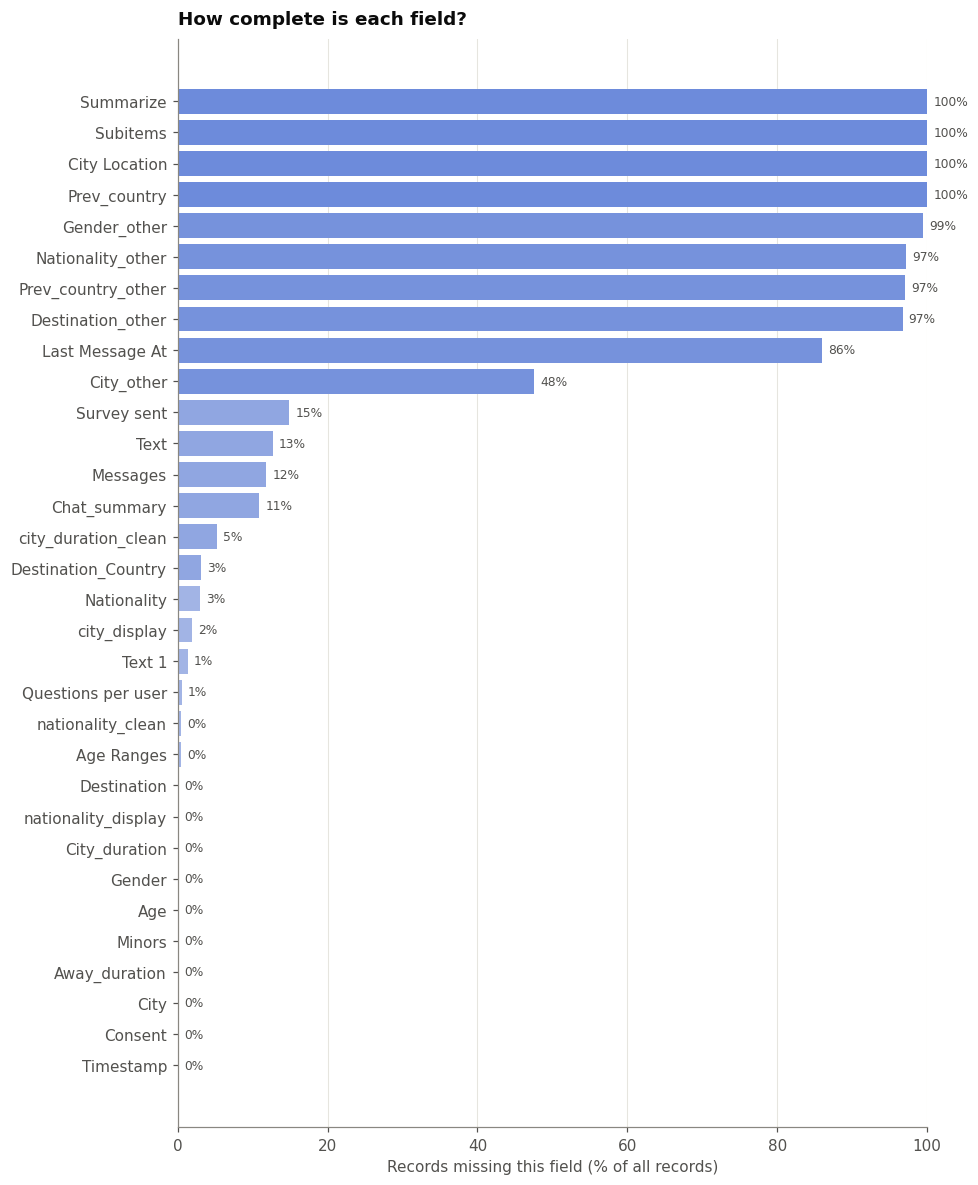

In [5]:
# Share of records missing, per field (only fields with any gaps), high -> low.
miss = df.isnull().mean()
miss = miss[miss > 0].sort_values()

fig, ax = plt.subplots(figsize=(9, max(3, len(miss) * 0.34)))
bars = ax.barh(miss.index, miss.values * 100, color=seq_colors(len(miss)))
ax.bar_label(bars, labels=[f"{v*100:.0f}%" for v in miss.values],
             padding=4, fontsize=8, color=INK2)
ax.set_xlim(0, 100)
ax.set_xlabel('Records missing this field (% of all records)')
ax.set_ylabel('')
ax.grid(True, axis='x')
ax.set_title('How complete is each field?')
plt.tight_layout()
plt.show()

In [6]:
missing = df.isnull().mean().sort_values(ascending=False)
print("Missingness rate:")
print(missing[missing > 0].map(lambda x: f"{x:.1%}").to_string())
print(f"\nDuplicate Name entries: {df['Name'].duplicated().sum()}")
print(f"Unique users:            {df['Name'].nunique()}")
print(f"Date range:              {df['Timestamp'].min().date()} -> {df['Timestamp'].max().date()}")

Missingness rate:
Subitems               100.0%
Prev_country           100.0%
City Location          100.0%
Summarize              100.0%
Gender_other            99.5%
Nationality_other       97.1%
Prev_country_other      97.0%
Destination_other       96.7%
Last Message At         86.0%
City_other              47.5%
Survey sent             14.9%
Text                    12.7%
Messages                11.8%
Chat_summary            10.9%
city_duration_clean      5.3%
Destination_Country      3.1%
Nationality              3.0%
city_display             1.9%
Text 1                   1.4%
Questions per user       0.5%
nationality_clean        0.4%
Age Ranges               0.4%
Minors                   0.1%
Consent                  0.1%
City                     0.1%
City_duration            0.1%
Away_duration            0.1%
Gender                   0.1%
Age                      0.1%
Destination              0.1%
Timestamp                0.1%
nationality_display      0.1%

Duplicate Name entrie

## 3. Demographics

**What this shows:** A profile of *who* uses the chatbot — nationality, gender, age (as both a distribution and generational cohorts), and how many users are responsible for minors in their care.

**Why it matters:** Knowing the audience shapes everything else the program does, from the language and tone Sami uses to the services it points people toward. A user base skewed toward families with children, for instance, has very different needs from one of mostly single adults — and outreach, content, and partner referrals should reflect that.

### 3.1 Nationality

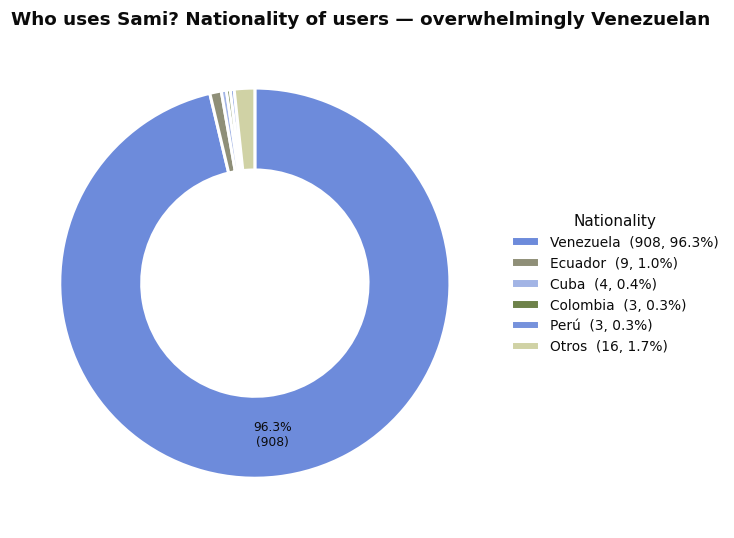

In [7]:
# Which nationalities use the chatbot, and in what proportion? Top 5 + "Otros",
# on a donut with each slice labelled by share and (count). nationality_clean
# already merged duplicate spellings and dropped junk values (Section 1).
nat = df['nationality_clean'].value_counts()
data = nat.head(5).copy()
otros = int(nat.iloc[5:].sum())
if otros:
    data['Otros'] = otros

fig, ax = plt.subplots(figsize=(7.5, 5))
wedges, _t, _a = ax.pie(
    data.values, colors=cat_colors(len(data)),
    autopct=pct_count_autopct(data.values), pctdistance=0.78,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor=SURFACE, linewidth=2),
    textprops=dict(fontsize=8, color=INK))
ax.legend(wedges, [f"{k}  ({v}, {v/data.sum()*100:.1f}%)" for k, v in data.items()],
          title='Nationality', loc='center left', bbox_to_anchor=(1.0, 0.5),
          fontsize=9, frameon=False)
ax.set_title('Who uses Sami? Nationality of users — overwhelmingly Venezuelan')
plt.tight_layout()
plt.show()

### 3.2 Gender

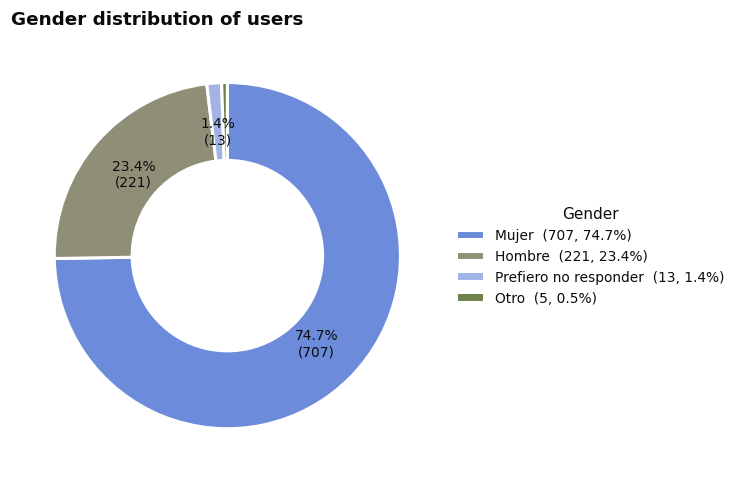

'Otro' breakdown (5 of 947 users):
  - 'Mujer'
  - 'Soy una mujer trans'
  - 'transgenero'
  - 'Gay'
  - 'lgtbQ+'


In [8]:
# How is the user base distributed across genders? Share + count per slice.
gender = df['Gender'].value_counts()
fig, ax = plt.subplots(figsize=(6.5, 4.5))
wedges, _t, _a = ax.pie(
    gender.values, colors=cat_colors(len(gender)),
    autopct=pct_count_autopct(gender.values, min_pct=1.0), pctdistance=0.72,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor=SURFACE, linewidth=2),
    textprops=dict(fontsize=9, color=INK))
ax.legend(wedges, [f"{k}  ({v}, {v/gender.sum()*100:.1f}%)" for k, v in gender.items()],
          title='Gender', loc='center left', bbox_to_anchor=(1.0, 0.5),
          fontsize=9, frameon=False)
ax.set_title('Gender distribution of users')
plt.tight_layout()
plt.show()

# What does "Otro" actually mean? Surface the free-text each respondent typed.
otro_detail = df.loc[df['Gender'] == 'Otro', 'Gender_other'].dropna()
print(f"'Otro' breakdown ({len(otro_detail)} of {len(df)} users):")
for text in otro_detail:
    print(f"  - {text!r}")

### 3.3 Age

> **Technical note — reading the box plot.** The box spans the middle 50% of users (25th to 75th percentile); the line inside is the **median** age. The "whiskers" reach the furthest users still within 1.5× that middle range, and any dots beyond them are **outliers** (unusually old/young individuals). Read together with the histogram: the histogram shows the *shape* of the distribution, the box plot pins down the *centre and spread*.

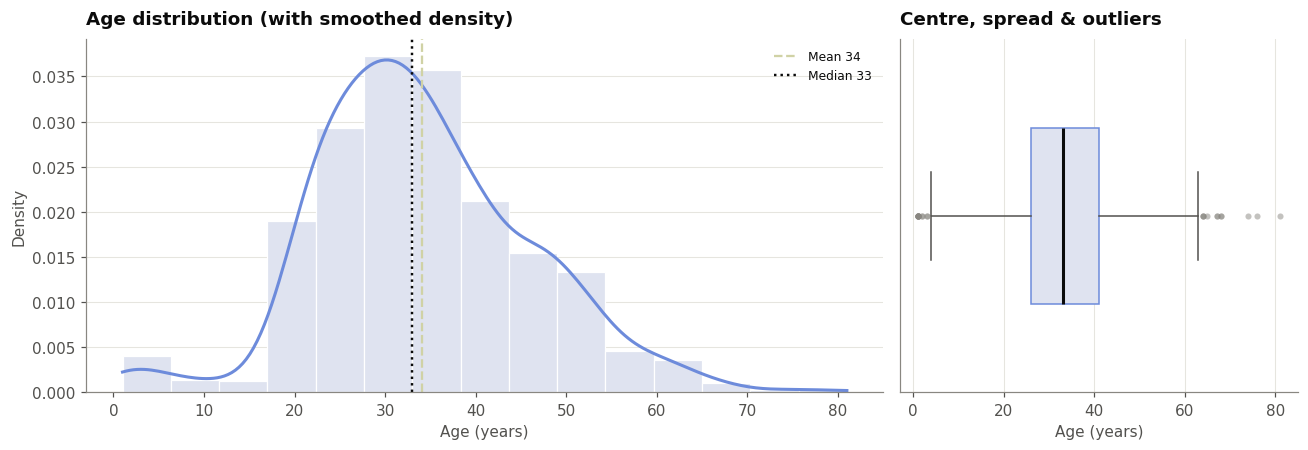

count    946.0
mean      34.1
std       11.9
min        1.0
25%       26.0
50%       33.0
75%       41.0
max       81.0


In [9]:
# Age profile: histogram (shape) with a smoothed density curve laid over it,
# next to a box plot (centre, spread, outliers).
age = df['Age'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2),
                         gridspec_kw={'width_ratios': [2, 1]})

axes[0].hist(age, bins=15, density=True, color=BLUE_SEQ[0],
             edgecolor=SURFACE, linewidth=0.8)
xs = np.linspace(age.min(), age.max(), 200)
axes[0].plot(xs, gaussian_kde(age)(xs), color=PRIMARY, linewidth=2)
axes[0].axvline(age.mean(), color=CAT[5], linestyle='--', linewidth=1.5,
                label=f'Mean {age.mean():.0f}')
axes[0].axvline(age.median(), color=INK, linestyle=':', linewidth=1.6,
                label=f'Median {age.median():.0f}')
axes[0].legend(fontsize=8, frameon=False)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Density')
axes[0].grid(True, axis='y')
axes[0].set_title('Age distribution (with smoothed density)')

axes[1].boxplot(age, vert=False, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=BLUE_SEQ[0], edgecolor=PRIMARY),
                medianprops=dict(color=INK, linewidth=2),
                whiskerprops=dict(color=INK2), capprops=dict(color=INK2),
                flierprops=dict(marker='o', markersize=4, markerfacecolor=MUTED,
                                markeredgecolor='none', alpha=0.5))
axes[1].set_yticks([])
axes[1].set_xlabel('Age (years)')
axes[1].grid(True, axis='x')
axes[1].set_title('Centre, spread & outliers')

plt.tight_layout()
plt.show()
print(age.describe().round(1).to_string())

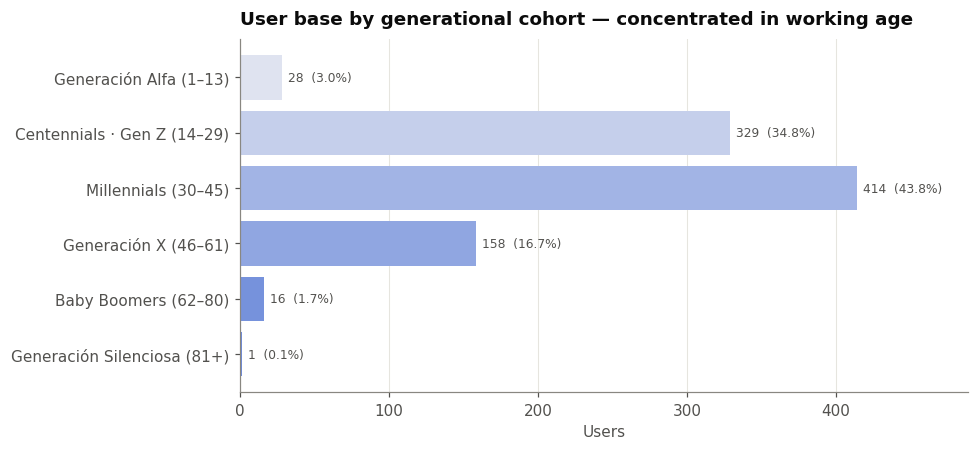

In [10]:
# User base by generational cohort. Bins follow the standard age brackets
# (as of 2025): Alfa 1-13, Gen Z 14-29, Millennials 30-45, Gen X 46-61,
# Baby Boomers 62-80, Silent 81+.
GEN_BINS = [0, 13, 29, 45, 61, 80, 200]
GEN_LABELS = [
    'Generación Alfa (1–13)',
    'Centennials · Gen Z (14–29)',
    'Millennials (30–45)',
    'Generación X (46–61)',
    'Baby Boomers (62–80)',
    'Generación Silenciosa (81+)',
]
gen = pd.cut(df['Age'].dropna(), bins=GEN_BINS, labels=GEN_LABELS, right=True)
gc = gen.value_counts().reindex(GEN_LABELS).fillna(0).astype(int)
total = gc.sum()

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.barh(gc.index, gc.values, color=seq_colors(len(gc)))
ax.bar_label(bars, labels=[f"{v}  ({v/total*100:.1f}%)" for v in gc.values],
             padding=4, fontsize=8, color=INK2)
ax.invert_yaxis()                       # youngest cohort on top
ax.set_xlim(0, gc.values.max() * 1.18)
ax.set_xlabel('Users')
ax.grid(True, axis='x')
ax.set_title('User base by generational cohort — concentrated in working age')
plt.tight_layout()
plt.show()

### 3.4 Care responsibilities

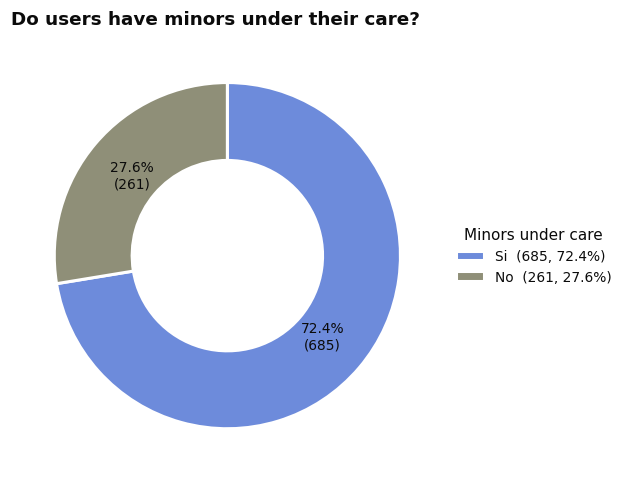

In [11]:
# How many users report having minors (children) under their care?
minors = df['Minors'].value_counts()
labels = minors.index.astype(str)
fig, ax = plt.subplots(figsize=(6, 4.5))
wedges, _t, _a = ax.pie(
    minors.values, colors=cat_colors(len(minors)),
    autopct=pct_count_autopct(minors.values, min_pct=1.0), pctdistance=0.72,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor=SURFACE, linewidth=2),
    textprops=dict(fontsize=9, color=INK))
ax.legend(wedges, [f"{k}  ({v}, {v/minors.sum()*100:.1f}%)" for k, v in zip(labels, minors.values)],
          title='Minors under care', loc='center left', bbox_to_anchor=(1.0, 0.5),
          fontsize=9, frameon=False)
ax.set_title('Do users have minors under their care?')
plt.tight_layout()
plt.show()

## 4. Geography

**What this shows:** *Where* users are and *how settled* they are — the cities with the most users, the mix of recent arrivals vs. long-term residents within each city, and a map of users across Colombia.

**Why it matters:** Location drives operational decisions. Knowing where users cluster helps prioritize which cities need in-person services or locally-tailored content. Layering in how long people have lived there adds nuance: recently-arrived migrants typically need orientation and legal-status help, while long-term residents need ongoing services — so two cities with similar user counts can have very different needs.

> **Technical note.** Cities use `city_display` (main answer + "Otra" free-text merged). The residency-mix chart is a **100% stacked bar** using the normalized `city_duration_clean` buckets, so the *proportion* of recent vs. settled users is comparable across cities regardless of sample size; the duration buckets are shaded on an ordered light→dark ramp (grey = "No especifica"). The map draws one bubble per city over a real basemap, sized by user count (bubble **area**, √-scaled, is a rough visual cue — not a precise scale).

### 4.1 Cities

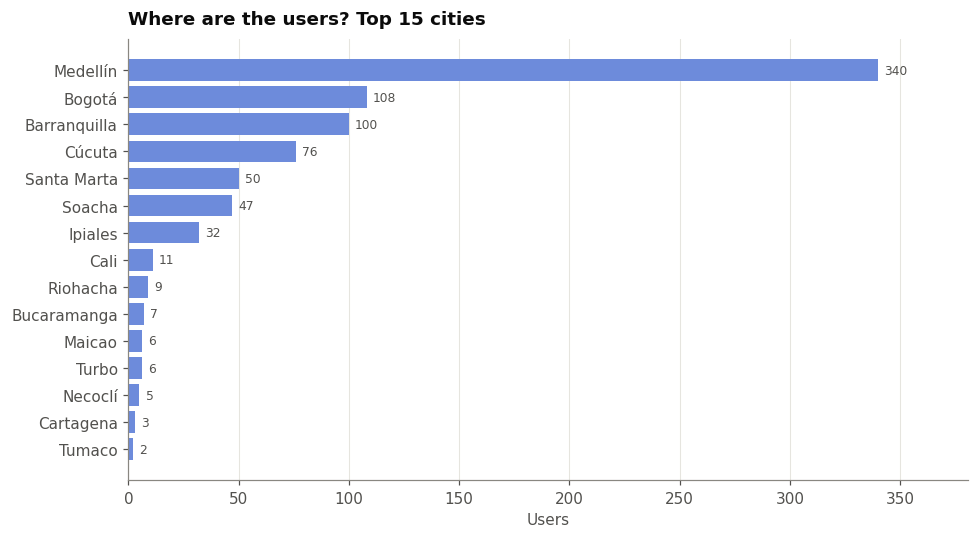

In [12]:
# Which cities have the most chatbot users? Where the audience concentrates.
city = df['city_display'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(city.index[::-1], city.values[::-1], color=PRIMARY)
ax.bar_label(bars, padding=4, fontsize=8, color=INK2)
ax.set_xlabel('Users')
ax.grid(True, axis='x')
ax.set_xlim(0, city.max() * 1.12)
ax.set_title('Where are the users? Top 15 cities')
plt.tight_layout()
plt.show()

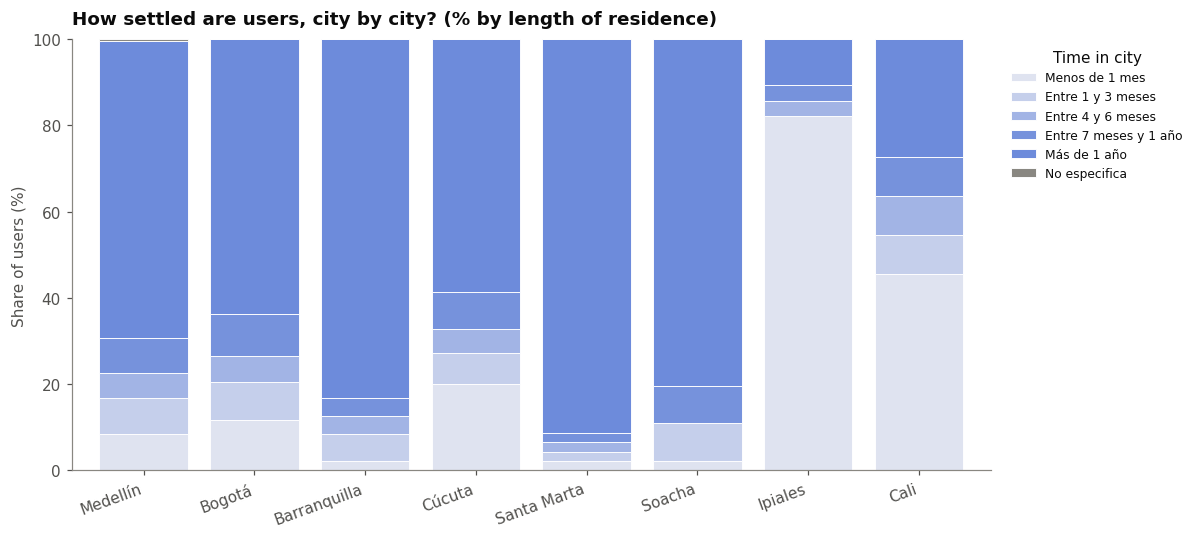

In [13]:
# For each major city, what share are recent arrivals vs long-settled? A 100%
# stacked bar makes the *mix* comparable across cities regardless of sample size.
top_cities = df['city_display'].value_counts().head(8).index
cross = (
    df[df['city_display'].isin(top_cities)]
    .dropna(subset=['city_display', 'city_duration_clean'])
    .groupby(['city_display', 'city_duration_clean']).size()
    .unstack(fill_value=0)
)
cols = [c for c in DURATION_ORDER if c in cross.columns]
cross_pct = cross[cols].div(cross[cols].sum(axis=1), axis=0) * 100
cross_pct = cross_pct.reindex([c for c in top_cities if c in cross_pct.index])

# ordered light->dark ramp for the duration buckets; grey for "No especifica"
_seq = seq_colors(len([c for c in cols if c != 'No especifica']))
_i = 0
dur_colors = []
for c in cols:
    if c == 'No especifica':
        dur_colors.append(MUTED)
    else:
        dur_colors.append(_seq[_i]); _i += 1

ax = cross_pct.plot(kind='bar', stacked=True, color=dur_colors,
                    figsize=(11, 5), edgecolor=SURFACE, linewidth=0.6, width=0.8)
ax.set_title('How settled are users, city by city? (% by length of residence)')
ax.set_xlabel('')
ax.set_ylabel('Share of users (%)')
ax.set_ylim(0, 100)
ax.legend(title='Time in city', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, frameon=False)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 4.2 Map

The map is built in two short steps — first the city coordinates and counts, then the plot with a basemap.

In [14]:
# Step 1 -- build the city bubbles (hard-coded centroids + user counts).
# city_display is already canonicalized in Section 1, so each city is one name.
CITY_COORDS = {   # (lon, lat)
    "Medellín": (-75.5812, 6.2442), "Cúcuta": (-72.5078, 7.8939),
    "Ipiales": (-77.6453, 0.8297), "Necoclí": (-76.7858, 8.4280),
    "Bogotá": (-74.0721, 4.7110), "Soacha": (-74.2170, 4.5790),
    "Barranquilla": (-74.7964, 10.9639), "Cali": (-76.5320, 3.4516),
    "Turbo": (-76.7305, 8.0979), "Santa Marta": (-74.2139, 11.2408),
    "Tumaco": (-78.8168, 1.8070), "Maicao": (-72.2427, 11.3703),
    "Riohacha": (-72.9072, 11.5442), "Galapa": (-74.8860, 10.8990),
    "Cartagena": (-75.5144, 10.3910), "Bucaramanga": (-73.1198, 7.1293),
    "Pereira": (-75.6942, 4.8087), "Armenia": (-75.6810, 4.5339),
    "Manizales": (-75.5174, 5.0703), "Pasto": (-77.2811, 1.2136),
    "Villavicencio": (-73.6354, 4.1420),
}
city_counts = (
    df['city_display'][df['city_display'].isin(CITY_COORDS)].value_counts()
    .rename_axis('city').reset_index(name='count')
)
city_counts['geometry'] = city_counts['city'].map(lambda c: Point(CITY_COORDS[c]))
cities_gdf = gpd.GeoDataFrame(city_counts, geometry='geometry', crs='EPSG:4326').to_crs(3857)
cities_gdf[['city', 'count']].head()

,city,count
0,Medellín,340
1,Bogotá,108
2,Barranquilla,100
3,Cúcuta,76
4,Santa Marta,50


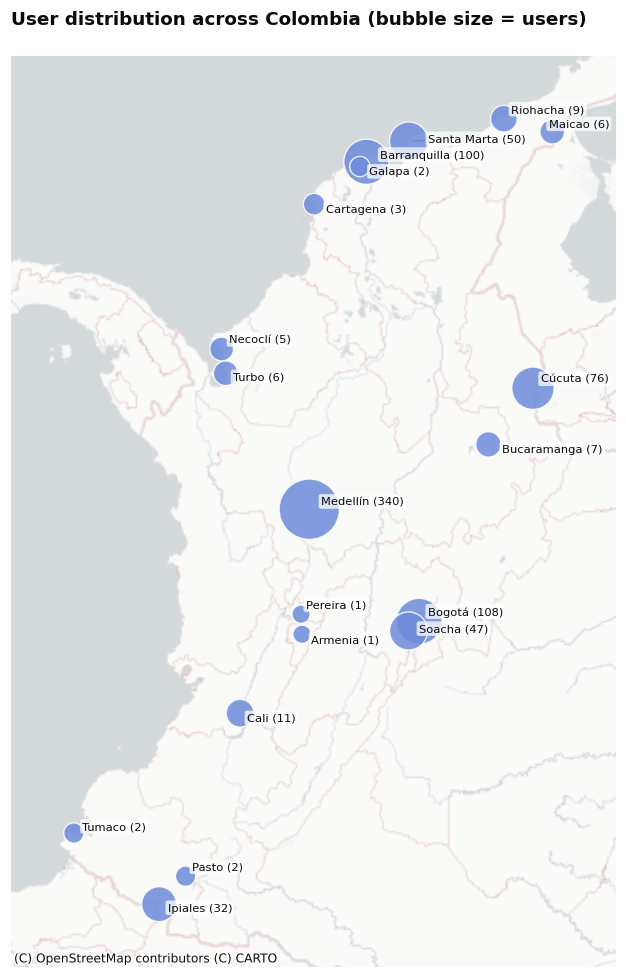

In [15]:
# Step 2 -- plot the bubbles over a real basemap so the geography is grounded.
mx = cities_gdf['count'].max()
cities_gdf['ms'] = np.sqrt(cities_gdf['count'] / mx) * 1500 + 60

fig, ax = plt.subplots(figsize=(7.5, 9))
cities_gdf.plot(ax=ax, markersize=cities_gdf['ms'], color=PRIMARY, alpha=0.85,
                edgecolor='white', linewidth=0.9, zorder=3)

# Equal padding in metres + equal aspect so the map keeps true proportions
# (otherwise the frame stretches the country sideways).
minx, miny, maxx, maxy = cities_gdf.total_bounds
pad = max(maxx - minx, maxy - miny) * 0.08
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)
ax.set_aspect('equal')
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=cities_gdf.crs)

texts = [
    ax.text(r.geometry.x, r.geometry.y, f"{r['city']} ({r['count']})",
            fontsize=7.5, color=INK, zorder=5,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75, ec='none'))
    for _, r in cities_gdf.iterrows()
]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color=INK2, lw=0.6))

ax.set_axis_off()
ax.set_title('User distribution across Colombia (bubble size = users)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Migration Routes

**What this shows:** The migration journey itself — how long users have been away from their home country, and a single map tying together which countries they came *from* and where they hope to go *next*.

**Why it matters:** Sami's users aren't a static population; many are mid-journey. Understanding the routes — who's just left home, who's transiting through, who's trying to reach a further destination — helps the program anticipate needs and coordinate with partner organizations along those corridors.

> **Technical note.** Time-away uses the structured `Away_duration` field. The routes map combines two sources: **origins** come from the free-text `Prev_country_other` (the structured `Prev_country` field is 100% empty), normalized for capitalization, with Colombian nationals added as "Colombia" since they never crossed a border; **destinations** come from `Destination_Country`. Both are canonicalized (e.g. `United States`→`Estados Unidos`) and non-countries (`Valyria`, `Valledupar`) dropped. Bubble size is √-scaled by user count. A handful of European origins fall outside the map frame and are listed beneath it.

### 5.1 Time away from country of origin

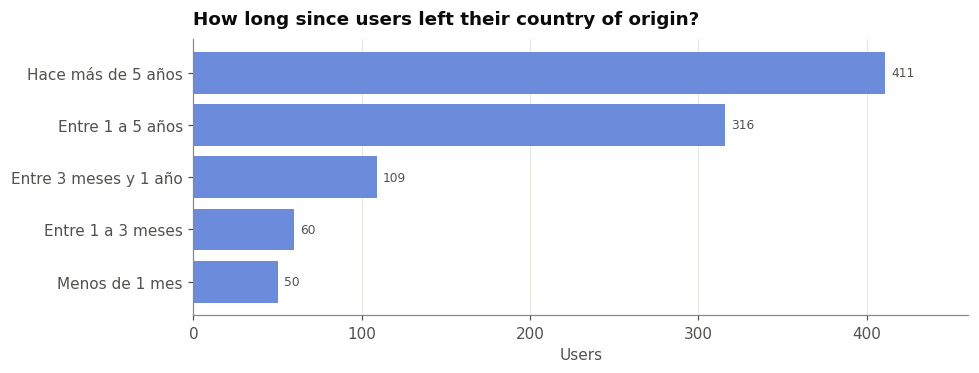

In [16]:
# How long has it been since users left their country of origin?
away = df['Away_duration'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, max(3.5, len(away) * 0.4)))
bars = ax.barh(away.index, away.values, color=PRIMARY)
ax.bar_label(bars, padding=4, fontsize=8, color=INK2)
ax.set_xlabel('Users')
ax.grid(True, axis='x')
ax.set_xlim(0, away.max() * 1.12)
ax.set_title('How long since users left their country of origin?')
plt.tight_layout()
plt.show()

### 5.2 Origin → destination map

In [17]:
# Step 1 -- build origin (previous country) and destination bubbles.
COUNTRY_CANON = {'United States': 'Estados Unidos', 'Peru': 'Perú',
                 'Panama': 'Panamá', 'Brazil': 'Brasil'}
NON_COUNTRY = {'Valyria', 'Valledupar'}
COUNTRY_COORDS = {   # (lon, lat)
    'Colombia': (-74.3, 4.6), 'Venezuela': (-66.6, 6.4), 'Chile': (-71.5, -35.7),
    'Brasil': (-51.9, -14.2), 'Cuba': (-79.5, 21.5), 'Haití': (-72.3, 18.9),
    'Argentina': (-63.6, -38.4), 'Panamá': (-80.0, 8.4), 'Ecuador': (-78.2, -1.8),
    'Perú': (-75.0, -9.2), 'Estados Unidos': (-98.5, 39.8),
    'Luxemburgo': (6.1, 49.8), 'Bulgaria': (25.5, 42.7), 'España': (-3.7, 40.4),
    'Alemania': (10.4, 51.2),
}

def canon_country(s):
    s = str(s).strip().title()
    return COUNTRY_CANON.get(s, s)

# Origins: previous country + Colombian nationals (who never crossed a border)
orig = df['Prev_country_other'].dropna().map(canon_country)
orig = orig[~orig.isin(NON_COUNTRY)].value_counts()
n_col = int((df['nationality_clean'] == 'Colombia').sum())
if n_col:
    orig['Colombia'] = orig.get('Colombia', 0) + n_col
# Destinations
dest = df['Destination_Country'].dropna().map(canon_country)
dest = dest[~dest.isin(NON_COUNTRY)].value_counts()

def build_gdf(counts):
    rows = [{'country': c, 'count': int(n), 'geometry': Point(COUNTRY_COORDS[c])}
            for c, n in counts.items() if c in COUNTRY_COORDS]
    return gpd.GeoDataFrame(rows, geometry='geometry', crs='EPSG:4326')

orig_gdf = build_gdf(orig)
dest_gdf = build_gdf(dest)
# Countries off the Americas frame (a few European origins) -- noted under the map
off_map = [(c, int(n)) for c, n in orig.items()
           if c in COUNTRY_COORDS and COUNTRY_COORDS[c][0] > -30]
orig_gdf = orig_gdf[orig_gdf.geometry.x < -30].to_crs(3857)
dest_gdf = dest_gdf.to_crs(3857)
print("Origins:", orig.to_dict())
print("Destinations:", dest.to_dict())

Origins: {'Chile': 12, 'Brasil': 2, 'Cuba': 2, 'Panamá': 2, 'Luxemburgo': 1, 'Bulgaria': 1, 'Haití': 1, 'Argentina': 1, 'Venezuela': 1, 'Colombia': 4, 'España': 1, 'Alemania': 1}
Destinations: {'Colombia': 809, 'Venezuela': 60, 'Estados Unidos': 24, 'Argentina': 18, 'Chile': 5, 'Ecuador': 1, 'Perú': 1}


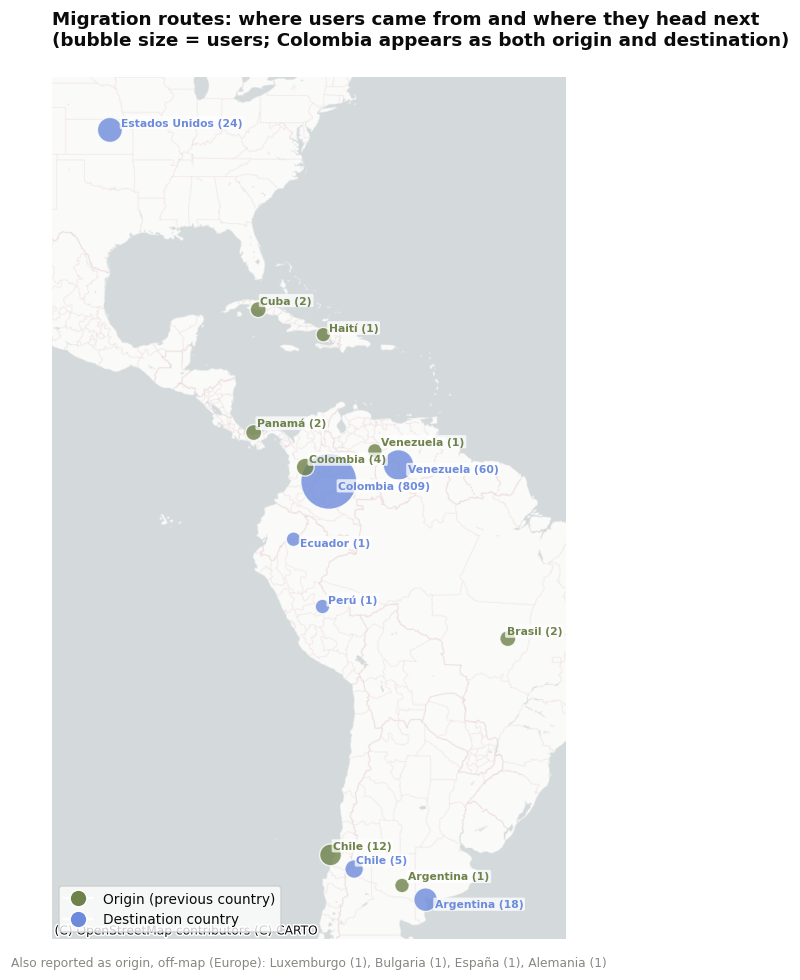

In [18]:
# Step 2 -- one map, colour key = origin vs destination, size = users.
ORIG_COLOR, DEST_COLOR = '#6e824a', '#6D8BDB'   # brand green = origin, blue = destination
mx = max(orig_gdf['count'].max(), dest_gdf['count'].max())

def msize(g):
    return np.sqrt(g['count'] / mx) * 1300 + 45

xs = list(orig_gdf.geometry.x) + list(dest_gdf.geometry.x)
ys = list(orig_gdf.geometry.y) + list(dest_gdf.geometry.y)
# Where a country is both an origin AND a destination (Colombia, Venezuela,
# Chile) the two bubbles sit on the same point. Nudge origins up-left and
# destinations down-right by a small fixed vector so both stay visible.
off = min(max(xs) - min(xs), max(ys) - min(ys)) * 0.028
ox, oy = orig_gdf.geometry.x - off, orig_gdf.geometry.y + off * 0.6
dx, dy = dest_gdf.geometry.x + off, dest_gdf.geometry.y - off * 0.6

fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(dx, dy, s=msize(dest_gdf), color=DEST_COLOR, alpha=0.8,
           edgecolor='white', linewidth=0.9, zorder=3)
ax.scatter(ox, oy, s=msize(orig_gdf), color=ORIG_COLOR, alpha=0.8,
           edgecolor='white', linewidth=0.9, zorder=4)

pad = max(max(xs) - min(xs), max(ys) - min(ys)) * 0.06
ax.set_xlim(min(xs) - pad, max(xs) + pad)
ax.set_ylim(min(ys) - pad, max(ys) + pad)
ax.set_aspect('equal')
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs='EPSG:3857')

texts = []
for gx, gy, g, col in [(dx, dy, dest_gdf, DEST_COLOR), (ox, oy, orig_gdf, ORIG_COLOR)]:
    for (x_, y_), (_, r) in zip(zip(gx, gy), g.iterrows()):
        texts.append(ax.text(x_, y_, f"{r['country']} ({r['count']})",
                             fontsize=7, color=col, fontweight='bold', zorder=6,
                             bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.75, ec='none')))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color=INK2, lw=0.5))

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ORIG_COLOR,
                  markersize=11, label='Origin (previous country)'),
           Line2D([0], [0], marker='o', color='w', markerfacecolor=DEST_COLOR,
                  markersize=11, label='Destination country')]
ax.legend(handles=handles, loc='lower left', frameon=True, fontsize=9)
ax.set_axis_off()
ax.set_title('Migration routes: where users came from and where they head next\n'
             '(bubble size = users; Colombia appears as both origin and destination)',
             fontsize=12)
if off_map:
    note = 'Also reported as origin, off-map (Europe): ' + ', '.join(f"{c} ({n})" for c, n in off_map)
    ax.text(0.5, -0.02, note, transform=ax.transAxes, ha='center', va='top',
            fontsize=8, color=MUTED)
plt.tight_layout()
plt.show()

## 6. Chatbot Engagement

**What this shows:** *How* users actually interact with Sami — the topics they ask about, how many questions a typical user asks, what share were sent the follow-up survey, and how daily usage has changed over time.

**Why it matters:** This is where we see whether Sami is doing its job. The topic mix shows what people actually need help with (and where content should be strengthened); the questions-per-user distribution shows whether people get a quick answer and leave or stay for a real conversation; and the usage timeline reveals growth, drop-offs, and spikes that often line up with outreach campaigns or external events.

> **Technical note.** Topics come from `Chat_summary`, an LLM-generated free-text field that needs cleaning before counting: one row contains leftover prompt instructions (dropped), some rows separate topics with `''` instead of commas, some are written as hashtags (`#legal_documentation`), and capitalization is inconsistent. `TOPIC_MAP` normalizes everything to 7 canonical categories. Questions-per-user is shown as a **summary table rather than a histogram** because most users ask 0–4 questions, so a histogram would pile almost everything into one or two bins. The usage timeline is a daily resample of `Timestamp`.

### 6.1 Topics discussed

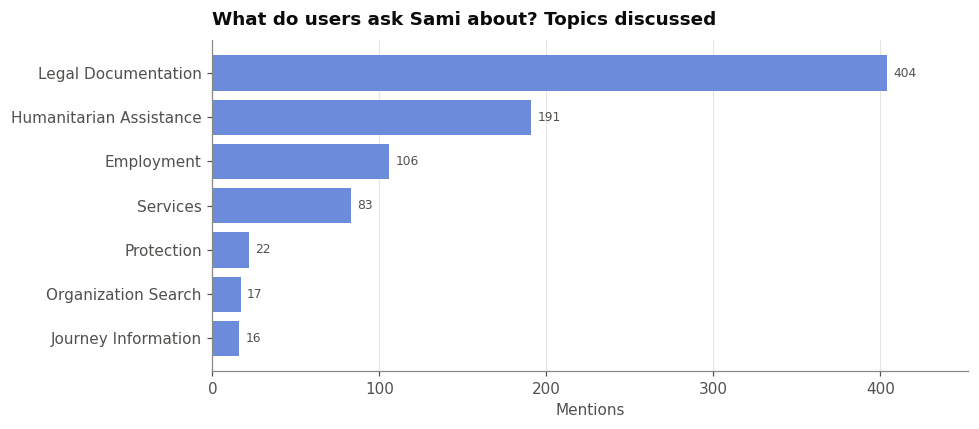

In [19]:
# What topics are users asking about? Chat_summary is free-text/LLM-generated
# with several inconsistencies (leftover prompt text, "''" separators, hashtags,
# mixed case); TOPIC_MAP normalizes down to 7 canonical categories.
TOPIC_MAP = {
    'legal documentation': 'Legal Documentation',
    'humanitarian assistance': 'Humanitarian Assistance',
    'employment': 'Employment', 'services': 'Services', 'protection': 'Protection',
    'organization search': 'Organization Search',
    'journey information': 'Journey Information',
}
raw = df['Chat_summary'].dropna()
raw = raw[~raw.str.contains('Use exactly one of these hashtags', na=False)]
topics = (
    raw.str.replace("''", ',', regex=False).str.split(',').explode()
    .str.strip().str.lstrip('#').str.replace('_', ' ', regex=False).str.lower()
    .map(TOPIC_MAP).dropna().value_counts()
)

fig, ax = plt.subplots(figsize=(9, max(4, len(topics) * 0.45)))
bars = ax.barh(topics.index[::-1], topics.values[::-1], color=PRIMARY)
ax.bar_label(bars, padding=4, fontsize=8, color=INK2)
ax.set_xlabel('Mentions')
ax.grid(True, axis='x')
ax.set_xlim(0, topics.max() * 1.12)
ax.set_title('What do users ask Sami about? Topics discussed')
plt.tight_layout()
plt.show()

### 6.2 Questions per user

In [20]:
# How many questions does a typical user ask? A histogram isn't useful (almost
# everyone asks 0-4), so a summary + distribution table communicates it better.
qs = df['Questions per user'].dropna()
print("Questions per user — summary statistics:")
print(qs.describe().round(2).to_string())
print()
counts = qs.value_counts().sort_index()
summary = pd.DataFrame({
    'Questions asked': counts.index.astype(int),
    'Users': counts.values,
    'Share of users (%)': (counts.values / counts.sum() * 100).round(1),
})
print("Distribution by number of questions asked:")
print(summary.to_string(index=False))

Questions per user — summary statistics:
count    942.00
mean       1.59
std        2.18
min        0.00
25%        0.00
50%        1.00
75%        2.00
max       29.00

Distribution by number of questions asked:
 Questions asked  Users  Share of users (%)
               0    325                34.5
               1    265                28.1
               2    160                17.0
               3     82                 8.7
               4     45                 4.8
               5     17                 1.8
               6     17                 1.8
               7     10                 1.1
               8      8                 0.8
               9      5                 0.5
              10      1                 0.1
              11      2                 0.2
              14      1                 0.1
              15      3                 0.3
              29      1                 0.1


### 6.3 Survey sent

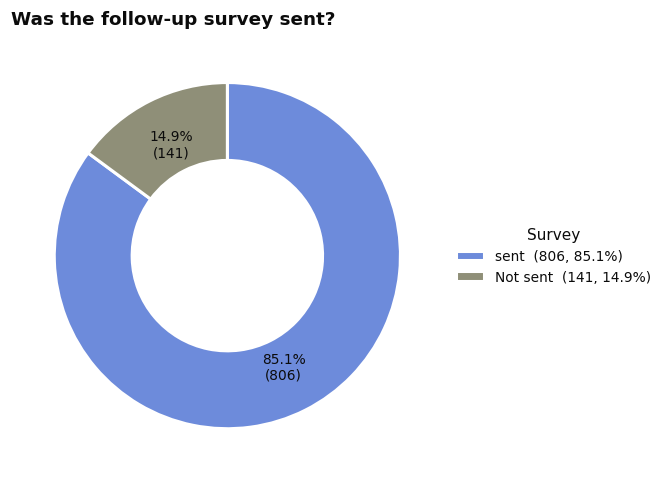

In [21]:
# What fraction of users were sent the post-conversation survey?
survey = df['Survey sent'].fillna('Not sent').value_counts()
fig, ax = plt.subplots(figsize=(6, 4.5))
wedges, _t, _a = ax.pie(
    survey.values, colors=cat_colors(len(survey)),
    autopct=pct_count_autopct(survey.values, min_pct=1.0), pctdistance=0.72,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor=SURFACE, linewidth=2),
    textprops=dict(fontsize=9, color=INK))
ax.legend(wedges, [f"{k}  ({v}, {v/survey.sum()*100:.1f}%)" for k, v in survey.items()],
          title='Survey', loc='center left', bbox_to_anchor=(1.0, 0.5),
          fontsize=9, frameon=False)
ax.set_title('Was the follow-up survey sent?')
plt.tight_layout()
plt.show()

### 6.4 Usage over time

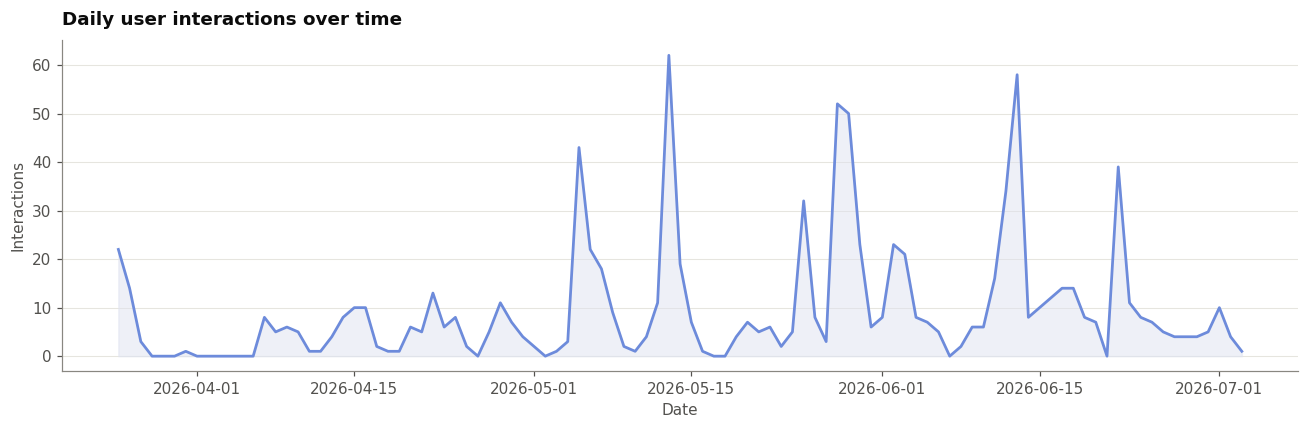

In [22]:
# How has daily chatbot usage evolved (growth, drop-offs, spikes)?
timeline = df.dropna(subset=['Timestamp']).set_index('Timestamp').resample('D').size()
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(timeline.index, timeline.values, color=BLUE_SEQ[0], alpha=0.5)
ax.plot(timeline.index, timeline.values, color=PRIMARY, linewidth=1.8)
ax.set_xlabel('Date')
ax.set_ylabel('Interactions')
ax.grid(True, axis='y')
ax.set_title('Daily user interactions over time')
plt.tight_layout()
plt.show()

## 7. Cross-cuts

**What this shows:** Two dimensions at a time, to surface patterns that single-variable charts can't reveal — gender composition within each nationality, average engagement by city, and age by destination country.

**Why it matters:** The most useful insights often live in the *combination* of factors. Whether one nationality skews toward a particular gender, whether some cities have markedly more engaged users, or whether people heading to different countries differ in age — these shape targeted outreach in ways that totals alone never could.

> **Technical note — small samples, careful reading.** Once the ~918 users are split across several categories, some cells contain very few people. The engagement-by-city chart annotates each bar with its sample size (`n=`), and the gender-composition chart shows the total users behind each nationality — so a bar built from 3 users isn't read with the same confidence as one from 80+. Treat thin bars as suggestive, not conclusive.

### 7.1 Gender composition by nationality

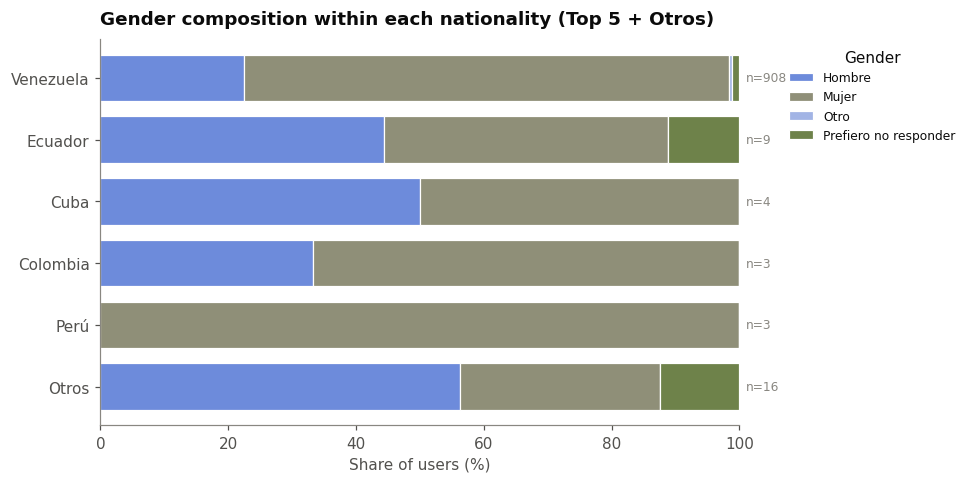

In [23]:
# Does gender balance differ by nationality? A 100% stacked bar shows the gender
# *composition* within each nationality (Top 5 + Otros) -- readable even where
# the raw counts are tiny (a plain count heatmap here is mostly zeros).
top_nat = df['nationality_clean'].value_counts().head(5).index.tolist()
tmp = df.dropna(subset=['Gender', 'nationality_clean']).copy()
tmp['nat_grp'] = tmp['nationality_clean'].where(tmp['nationality_clean'].isin(top_nat), 'Otros')
order = top_nat + ['Otros']
comp = tmp.groupby(['nat_grp', 'Gender']).size().unstack(fill_value=0).reindex(order).fillna(0)
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

ax = comp_pct.plot(kind='barh', stacked=True, color=cat_colors(comp_pct.shape[1]),
                   figsize=(9, 4.5), edgecolor=SURFACE, linewidth=0.8, width=0.75)
totals = comp.sum(axis=1)
for i, tot in enumerate(totals.values):
    ax.text(101, i, f"n={int(tot)}", va='center', fontsize=8, color=MUTED)
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.set_xlabel('Share of users (%)')
ax.set_ylabel('')
ax.legend(title='Gender', bbox_to_anchor=(1.06, 1), loc='upper left', fontsize=8, frameon=False)
ax.set_title('Gender composition within each nationality (Top 5 + Otros)')
plt.tight_layout()
plt.show()

### 7.2 Engagement by city

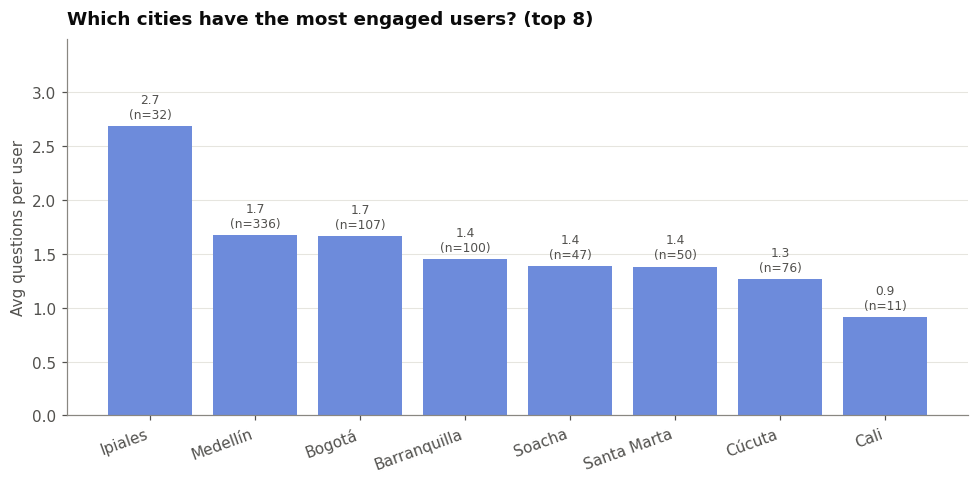

In [24]:
# Which cities have the most engaged users (avg questions per user)? Each bar is
# annotated with n= (users behind the average) so thin samples aren't over-read.
top_cities = df['city_display'].value_counts().head(8).index
city_eng = (
    df[df['city_display'].isin(top_cities)]
    .groupby('city_display')['Questions per user']
    .agg(mean='mean', n='count').sort_values('mean', ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(city_eng.index, city_eng['mean'], color=PRIMARY)
for bar, n in zip(bars, city_eng['n']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}\n(n={n})", ha='center', va='bottom', fontsize=8, color=INK2)
ax.set_ylim(0, city_eng['mean'].max() * 1.3)
ax.set_ylabel('Avg questions per user')
ax.grid(True, axis='y')
ax.set_xticklabels(city_eng.index, rotation=20, ha='right')
ax.set_title('Which cities have the most engaged users? (top 8)')
plt.tight_layout()
plt.show()

### 7.3 Age by destination country

> **Technical note — reading these box plots.** Each box spans the middle 50% of ages for users heading to that country, with the median marked inside; whiskers reach the furthest users within 1.5× that range and dots beyond are outliers. Boxes built from few users (narrow destinations like Ecuador/Peru) are far less stable than Colombia's — compare shapes, but don't over-read a box drawn from a handful of people.

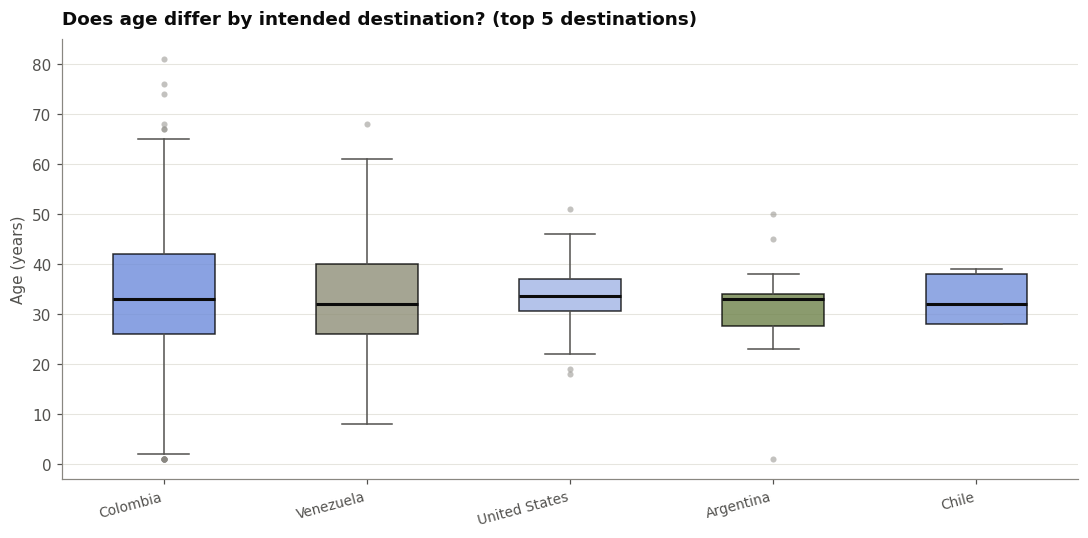

In [25]:
# Does the age profile differ by intended destination country?
top_dests = df['Destination_Country'].value_counts().head(5).index.tolist()
subset = df[df['Destination_Country'].isin(top_dests)]
groups = [subset.loc[subset['Destination_Country'] == d, 'Age'].dropna().values for d in top_dests]
groups = [(g if len(g) else np.array([np.nan])) for g in groups]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(groups, patch_artist=True, vert=True,
                medianprops=dict(color=INK, linewidth=2),
                whiskerprops=dict(color=INK2), capprops=dict(color=INK2),
                flierprops=dict(marker='o', markersize=4, markerfacecolor=MUTED,
                                markeredgecolor='none', alpha=0.5))
for patch, color in zip(bp['boxes'], cat_colors(len(top_dests))):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(top_dests, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Age (years)')
ax.grid(True, axis='y')
ax.set_title('Does age differ by intended destination? (top 5 destinations)')
plt.tight_layout()
plt.show()